In [2]:
import os
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import clone

from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
)

from sklearn.calibration import calibration_curve

import joblib, json

In [3]:
DATA_PATHS = [
    "online_gaming_behavior_dataset.csv",
    "/mnt/data/online_gaming_behavior_dataset.csv"
]

for p in DATA_PATHS:
    if os.path.exists(p):
        DATA_PATH = p
        break
else:
    raise FileNotFoundError("Dataset not found in expected paths.")

df = pd.read_csv(DATA_PATH)
DATA_PATH

'online_gaming_behavior_dataset.csv'

In [4]:
df["y"] = (
    df["EngagementLevel"]
      .astype(str)
      .str.strip()
      .str.lower()
      .eq("low")
      .astype(int)
)

print(df["y"].value_counts())
print(df["y"].value_counts(normalize=True))

y
0    29710
1    10324
Name: count, dtype: int64
y
0    0.742119
1    0.257881
Name: proportion, dtype: float64


## Model context
The threshold analysis is based on the **Gradient Boosting classifier**, selected due to:
- strong cross-validated F1-score and average precision,
- stable recall for the churn-risk proxy class,
- good separation under ROC-AUC and PR-AUC

The preprocessing pipeline, feature set and train/test split are kept **identical** to the main notebook

In [5]:
candidate_features = [
    "Age",
    "Gender",
    "Location",
    "GameGenre",
    "GameDifficulty",
    "PlayTimeHours",
    "SessionsPerWeek",
    "AvgSessionDurationMinutes",
    "PlayerLevel",
    "AchievementsUnlocked",
    "InGamePurchases"
]

missing = [c for c in candidate_features if c not in df.columns]
if missing:
    raise KeyError(f"Missing expected feature columns: {missing}")

X = df[candidate_features].copy()
y = df["y"].copy()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(y
 0    0.742124
 1    0.257876
 Name: proportion, dtype: float64,
 y
 0    0.742101
 1    0.257899
 Name: proportion, dtype: float64)

In [7]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

gb = Pipeline(steps=[
    ("preprocess", clone(preprocess)),
    ("model", GradientBoostingClassifier(
        random_state=42,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8
    ))
])

# OOF threshold scan

Out-of-fold probabilities are used to select the decision threshold to ensure the threshold is derivedd entirely from training data, preventing any leakage from the hgeld-out test set.

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Out-of-fold predicted probabilities for training set
oof_proba = cross_val_predict(
    gb,
    X_train, y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print("OOF ROC-AUC:", roc_auc_score(y_train, oof_proba))
print("OOF PR-AUC :", average_precision_score(y_train, oof_proba))

OOF ROC-AUC: 0.9416796885777515
OOF PR-AUC : 0.8872469670293445


In [9]:
thresholds = np.linspace(0.05, 0.95, 181)

rows = []
for t in thresholds:
    y_hat = (oof_proba >= t).astype(int)
    rows.append({
        "threshold": t,
        "precision": precision_score(y_train, y_hat, zero_division=0),
        "recall": recall_score(y_train, y_hat, zero_division=0),
        "f1": f1_score(y_train, y_hat, zero_division=0)
    })

thr_df = pd.DataFrame(rows)

best_row = thr_df.loc[thr_df["f1"].idxmax()]
best_t = float(best_row["threshold"])

print(f"Optimal OOF threshold: t={best_t:.3f}")
print(best_row)

Optimal OOF threshold: t=0.420
threshold    0.420000
precision    0.904066
recall       0.891149
f1           0.897561
Name: 74, dtype: float64


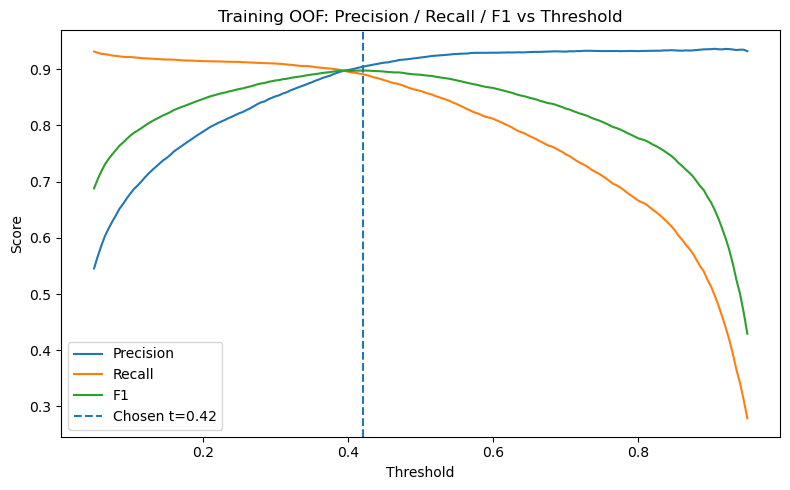

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(thr_df["threshold"], thr_df["precision"], label="Precision")
plt.plot(thr_df["threshold"], thr_df["recall"], label="Recall")
plt.plot(thr_df["threshold"], thr_df["f1"], label="F1")
plt.axvline(best_t, linestyle="--", label=f"Chosen t={best_t:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Training OOF: Precision / Recall / F1 vs Threshold")
plt.legend()
plt.tight_layout()
plt.savefig("threshold_scan.png", dpi=150)
plt.show()

# Probability Calibration Check
- Before applying the chosen threshold to the test set, the reliability of the GB probability outputs is verified.
- Calibration is also a prerequisite for the Streamlit dashboard threshold slider to produce trustworthy risk scores.

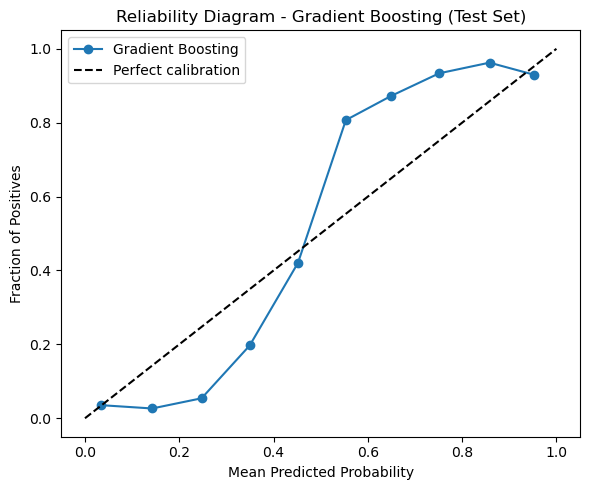

In [11]:
# Fit GB on full training set to obtain test set probabilities

gb.fit(X_train, y_train)
test_proba = gb.predict_proba(X_test)[:, 1]

# Reliability diagram
prob_true, prob_pred = calibration_curve(
    y_test, test_proba, n_bins=10, strategy="uniform"
)

fig, ax = plt.subplots(figsize=(6,5))
ax.plot(prob_pred, prob_true, marker="o", label="Gradient Boosting")
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.set_title("Reliability Diagram - Gradient Boosting (Test Set)")
ax.legend()
plt.tight_layout()
plt.savefig("calibration_curve.png", dpi=150)
plt.show()

In [12]:
# Brier Score

brier = np.mean((test_proba - y_test.values) ** 2)
brier_baseline = y_test.mean() * (1 - y_test.mean())

print(f"Brier Score (GB)           : {brier:.4f}")
print(f"Brier Score (no-skill ref) : {brier_baseline:.4f}")
print(f"Brier Score (lower=better) : {brier / brier_baseline:.4f}")

Brier Score (GB)           : 0.0525
Brier Score (no-skill ref) : 0.1914
Brier Score (lower=better) : 0.2743


# Final evaluation at chosen threshold (held-out test set)
- Results at t=0.50 (scikit-learn default) are reported alongside t=best_t to quantify the operational benefit of threshold adjustment under class imbalance.

In [13]:
def metrics_block(y_true, y_pred, y_proba):
    return {
        "ROC-AUC":   round(roc_auc_score(y_true, y_proba), 4),
        "PR-AUC":    round(average_precision_score(y_true, y_proba), 4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall":    round(recall_score(y_true, y_pred, zero_division=0), 4),
        "F1":        round(f1_score(y_true, y_pred, zero_division=0), 4),
    }

test_pred_default = (test_proba >= 0.50).astype(int)
test_pred_best    = (test_proba >= best_t).astype(int)

print("Test metrics threshold=0.50")
print(metrics_block(y_test, test_pred_default, test_proba))

print(f"\nTest metrics chosen threshold={best_t:.2f}")
print(metrics_block(y_test, test_pred_best, test_proba))

Test metrics threshold=0.50
{'ROC-AUC': 0.9382, 'PR-AUC': 0.8798, 'Precision': 0.9249, 'Recall': 0.8654, 'F1': 0.8942}

Test metrics chosen threshold=0.42
{'ROC-AUC': 0.9382, 'PR-AUC': 0.8798, 'Precision': 0.9025, 'Recall': 0.8828, 'F1': 0.8925}


In [14]:
# Side-by-side comparison table
comparison = pd.DataFrame({
    "t=0.50":          metrics_block(y_test, test_pred_default, test_proba),
    f"t={best_t:.2f}": metrics_block(y_test, test_pred_best,    test_proba), 
})

print("\nThreshold comparison (GB, test set):")
print(comparison)


Threshold comparison (GB, test set):
           t=0.50  t=0.42
ROC-AUC    0.9382  0.9382
PR-AUC     0.8798  0.8798
Precision  0.9249  0.9025
Recall     0.8654  0.8828
F1         0.8942  0.8925


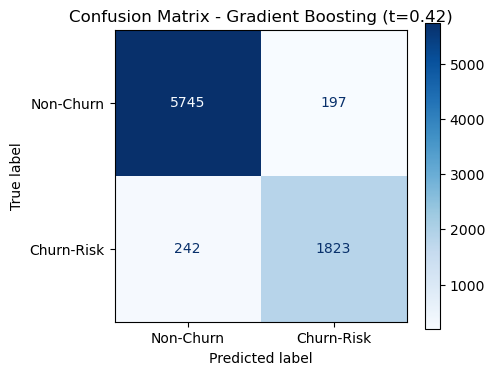

In [15]:
# Confusion matrix at chosen threshold

fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay.from_predictions(
    y_test, test_pred_best,
    display_labels=["Non-Churn", "Churn-Risk"],
    cmap="Blues", ax=ax
)
ax.set_title(f"Confusion Matrix - Gradient Boosting (t={best_t:.2f})")
plt.tight_layout()
plt.savefig("confusion_matrix_best_t.png", dpi=150)
plt.show()

In [16]:
# Normalised confusion matrix

cm = confusion_matrix(y_test, test_pred_best)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

print("Confusion matrix (counts):\n", cm)
print("\nConfusion matrix (row-normalized):\n", np.round(cm_norm, 3))

Confusion matrix (counts):
 [[5745  197]
 [ 242 1823]]

Confusion matrix (row-normalized):
 [[0.967 0.033]
 [0.117 0.883]]


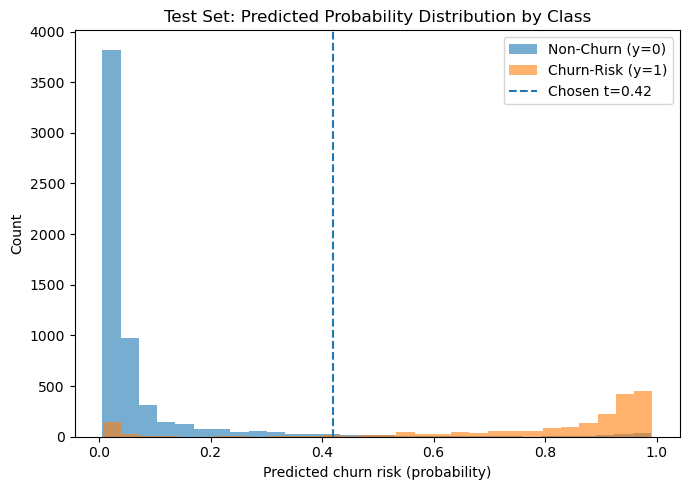

In [17]:
# Predicted probability distribution by class

plt.figure(figsize=(7, 5))
plt.hist(test_proba[y_test == 0], bins=30, alpha=0.6, label="Non-Churn (y=0)")
plt.hist(test_proba[y_test == 1], bins=30, alpha=0.6, label="Churn-Risk (y=1)")
plt.axvline(best_t, linestyle="--", label=f"Chosen t={best_t:.2f}")
plt.xlabel("Predicted churn risk (probability)")
plt.ylabel("Count")
plt.title("Test Set: Predicted Probability Distribution by Class")
plt.legend()
plt.tight_layout()
plt.savefig("proba_distribution.png", dpi=150)
plt.show()

# Bootstrap confidence intervals on test metrics
- Bootstrap resampling (1,000 resamples with replacement) is used to estimate 95% confidence intervals on all five test metrics at the chosen threshold, providing a more complete picture of model reliability than cross-validation alone

In [18]:
np.random.seed(42)
N_BOOT = 1000
test_proba_arr = np.array(test_proba)
y_test_arr = np.array(y_test)

boot_metrics = {"precision": [], "recall": [], "f1": [], 
                "roc_auc": [], "pr_auc": []}

for _ in range (N_BOOT):
    idx = np.random.choice(len(y_test_arr), size=len(y_test_arr), replace=True)
    yt  = y_test_arr[idx]
    ypr = test_proba_arr[idx]
    yp  = (ypr >= best_t).astype(int)
    if len(np.unique(yt)) < 2:
        continue
    try:
        boot_metrics["precision"].append(precision_score(yt, yp, zero_division=0))
        boot_metrics["recall"].append(recall_score(yt, yp, zero_division=0))
        boot_metrics["f1"].append(f1_score(yt, yp, zero_division=0))
        boot_metrics["roc_auc"].append(roc_auc_score(yt, ypr))
        boot_metrics["pr_auc"].append(average_precision_score(yt, yp))
    except Exception as e:
        continue

ci_rows = []
for metric, vals in boot_metrics.items():
    arr = np.array(vals)
    ci_rows.append({
        "Metric":   metric,
        "Mean":     round(arr.mean(), 4),
        "Std":      round(arr.std(), 4),
        "CI_lower": round(np.percentile(arr, 2.5), 4),
        "CI_upper": round(np.percentile(arr, 97.5), 4),
    })

ci_df = pd.DataFrame(ci_rows).set_index("Metric")

print(f"Bootstrap 95% CIs - GB at t={best_t:.2f} (n_boot={N_BOOT})")
print(ci_df)

Bootstrap 95% CIs - GB at t=0.42 (n_boot=1000)
             Mean     Std  CI_lower  CI_upper
Metric                                       
precision  0.9024  0.0064    0.8899    0.9145
recall     0.8831  0.0070    0.8694    0.8967
f1         0.8926  0.0050    0.8819    0.9023
roc_auc    0.9384  0.0039    0.9306    0.9458
pr_auc     0.8271  0.0078    0.8108    0.8419


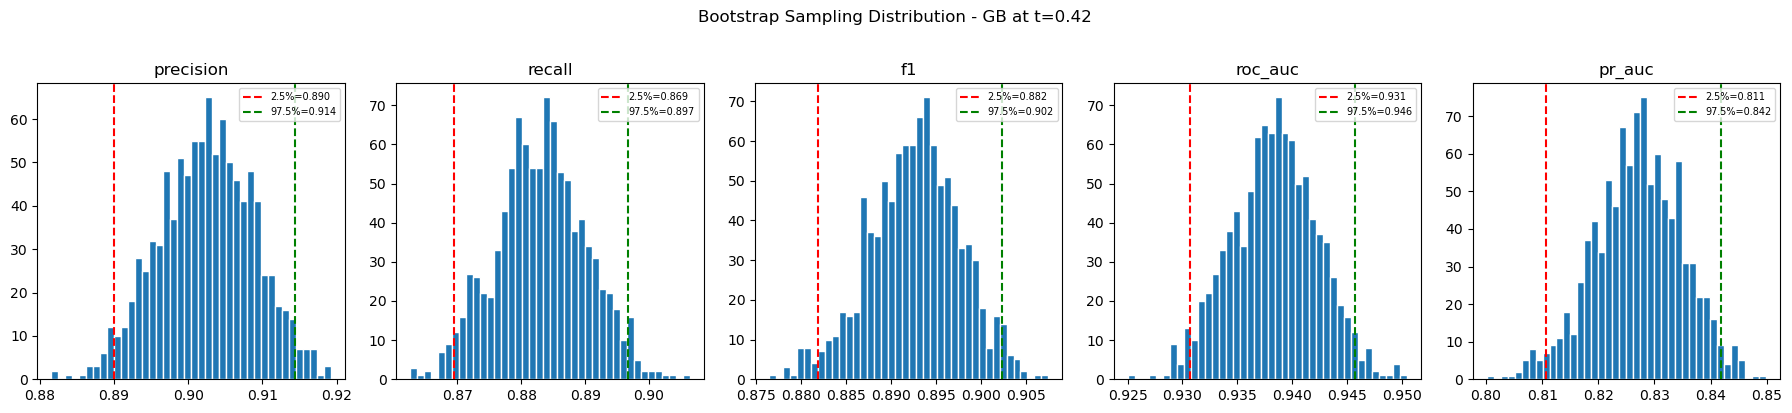

In [19]:
metric_keys = list(boot_metrics.keys())
fig, axes = plt.subplots(1, len(metric_keys), figsize=(18,4))

for i, metric in enumerate(metric_keys):
    arr = np.array(boot_metrics[metric])
    lo, hi = np.percentile(arr, [2.5, 97.5])
    axes[i].hist(arr, bins=40, edgecolor="white")
    axes[i].axvline(lo, linestyle="--", color="red", label=f"2.5%={lo:.3f}")
    axes[i].axvline(hi, linestyle="--", color="green", label=f"97.5%={hi:.3f}")
    axes[i].set_title(metric)
    axes[i].legend(fontsize=7)

plt.suptitle(f"Bootstrap Sampling Distribution - GB at t={best_t:.2f}", y=1.02)
plt.tight_layout()
plt.savefig("bootstrap_ci.png", dpi=150)
plt.show()

# Limitations
- The target remains a **churn-risk proxy**, not confirmed churn.
- Threshold selection maximises F1-score as a neutral criterion. In a deployment context, the threshold should be adjusted to reflect the business cost asymmetry between false positives (wasted retention spend) and false negatives (missed at-risk players).
- Bootstrap CIs assume test set observations are independent, which holds here as each row represents a distinct player profile.

In [20]:
os.makedirs("artifacts", exist_ok=True)

# Save trained pipeline
joblib.dump(gb, "artifacts/gb_churn_pipeline.joblib")

# Save test predictions for dashboard
preds = X_test.copy()
preds["y_true"]        = y_test.values
preds["proba_gb"]      = test_proba
preds["pred_gb_tuned"] = test_pred_best
preds.to_csv("artifacts/test_predictions_gb.csv", index=False)

# Save threshold and headline metrics
out = {
    "chosen_threshold":                 round(best_t, 2),
    "brier_score":                      round(brier, 4),
    "brier_baseline":                   round(brier_baseline, 4),
    "metrics_test_at_t0.5":             metrics_block(y_test,test_pred_default, test_proba),
    f"metrics_test_at_t{best_t:.2f}":    metrics_block(y_test, test_pred_best, test_proba),
    "bootstrap_95ci":   {
        m: {"mean":     round(np.mean(v), 4),
            "ci_lower": round(np.percentile(v, 2.5),4),
            "ci_upper": round(np.percentile(v, 97.5),4)}
        for m, v in boot_metrics.items()
    }
}
with open("artifacts/gb_threshold_metrics.json", "w") as f:
    json.dump(out, f, indent=2)

print("Artifacts saved to artifacts/")
print(json.dumps(out, indent=2))

Artifacts saved to artifacts/
{
  "chosen_threshold": 0.42,
  "brier_score": 0.0525,
  "brier_baseline": 0.1914,
  "metrics_test_at_t0.5": {
    "ROC-AUC": 0.9382,
    "PR-AUC": 0.8798,
    "Precision": 0.9249,
    "Recall": 0.8654,
    "F1": 0.8942
  },
  "metrics_test_at_t0.42": {
    "ROC-AUC": 0.9382,
    "PR-AUC": 0.8798,
    "Precision": 0.9025,
    "Recall": 0.8828,
    "F1": 0.8925
  },
  "bootstrap_95ci": {
    "precision": {
      "mean": 0.9024,
      "ci_lower": 0.8899,
      "ci_upper": 0.9145
    },
    "recall": {
      "mean": 0.8831,
      "ci_lower": 0.8694,
      "ci_upper": 0.8967
    },
    "f1": {
      "mean": 0.8926,
      "ci_lower": 0.8819,
      "ci_upper": 0.9023
    },
    "roc_auc": {
      "mean": 0.9384,
      "ci_lower": 0.9306,
      "ci_upper": 0.9458
    },
    "pr_auc": {
      "mean": 0.8271,
      "ci_lower": 0.8108,
      "ci_upper": 0.8419
    }
  }
}
